# 完全保存用の独立した再実行

このNotebookは notebooks/10_svd/10_mnist_mlp/02_rank_accuracy_tradeoff_corrected.ipynb の新規run。過去runの復元ではなく、baseline重み・全rankの未丸め値・FT各epoch履歴・測定条件を新しい出力先へ保存する。元の説明・条件・TODOを保持し、変更は出力先・進捗ログ・保存用セルだけ。

元Notebook中の「未実行」「過去の欠落」は複製元runへの説明。以下の新規runの実行状態は末尾のrun_manifest.jsonと各セルのexecution_countで確認する。

実行後の命名整理：Notebook名とEXPERIMENT_NAMEを `_rerun` に揃え、results/modelsの対応ディレクトリも改名した。学習・評価は再実行していない。セルの出力ログにある日時付き旧パスは実行当時の記録であり、現在の保存先はEXPERIMENT_NAMEとrun_manifest.jsonの各pathを参照する。数値・図・execution_countは改名前の実行結果を保持する。


In [1]:
# 独立した新規run。元Notebook/CSV/重みを上書きしない。
import sys
from pathlib import Path
_run_root = Path.cwd().resolve()
while not (_run_root / "src" / "nn_compression").is_dir() and _run_root.parent != _run_root:
    _run_root = _run_root.parent
sys.path.insert(0, str(_run_root / "src"))
RUN_BATCH_ID = 'rerun_20260912T074153Z'
RUN_SOURCE_RELATIVE = 'notebooks/10_svd/10_mnist_mlp/02_rank_accuracy_tradeoff_corrected.ipynb'
RUN_NOTEBOOK_RELATIVE = 'notebooks/10_svd/10_mnist_mlp/02_rank_accuracy_tradeoff_corrected_rerun.ipynb'
RUN_SOURCE_SNAPSHOT_SHA256 = '99d1c76bbf13b17cf4a4346e60dde2746e89e8624aa5a5ba0be11cddfcf5d832'
print("独立新規run:", RUN_BATCH_ID, RUN_SOURCE_RELATIVE)


独立新規run: rerun_20260912T074153Z notebooks/10_svd/10_mnist_mlp/02_rank_accuracy_tradeoff_corrected.ipynb


# 02_rank_accuracy_tradeoff（corrected）

原本 `02_rank_accuracy_tradeoff.ipynb` は **test set で rank を選んでいた** 歴史的実験として残す。
この corrected 版では役割を分ける。

```text
train（学習）
  ↓
validation（rank 選択・トレードオフの可視化）
  ↓
選んだ 1 組だけ test（最終確認）
```

test を rank 選択に使わない。保存先も原本と別にする。

## corrected版で変更した点

この Notebook は **SVD の数式を変えたものではない**。
原本 `02_rank_accuracy_tradeoff.ipynb` からの差分は、実験評価・再現性・現行 src の API 契約の修正である。

- **val/test 分離**: 原本は test で rank を選んでいた。corrected は train / Early Stopping 用 validation / rank 選択用 validation / test に分け、test は選んだ 1 組の最終確認だけに使う。
- **candidate 間の seed 公平化**: `SEED = 0` に固定し、学習直前に `set_seed(SEED)` と DataLoader Generator を同じ初期状態へ戻す。
- **DataLoader Generator 管理**: `loader_generator` を保持し、shuffle 順を再現できるようにする。
- **train_eval_loader**: 学習中の train 指標は `shuffle=False` の loader で測る。shuffle 付き `train_loader` は再走査しない。
- **同一 input batch の benchmark**: baseline と compressed で `take_inference_batch` した同じ入力を使う。
- **warmup / repeats の統一**: 原本は compressed 側の repeats が小さかった。corrected は両方 `BENCH_WARMUP=20`, `BENCH_REPEATS=200`。
- **model 非共有**: `make_two_layer_svd_model` は baseline を破壊せず、置換後の新しいモデルを返す。
- **include_model=False**: rank sweep 結果に PyTorch モデル本体を残さない。
- **corrected 専用保存先**: `02_rank_accuracy_tradeoff_corrected`。原本の results / models は上書きしない。

## 2026-09-12 保存成果物監査への対応

同一runのbaseline重みを学習直後に保存する処理を追加した。過去の保存出力は変更前runの記録であり、追加した保存処理は未実行。過去runの未保存baselineを別Notebookの重みで代用したり、再現できたことにはしていない。

保存出力の整合性と、現行コードのRun All成功は別の確認である。未実行の追加処理があるセルはexecution_countを空にし、既存outputは過去記録として保持した。


## 1. import

定型処理は `src/nn_compression/`。この Notebook には実験条件と解釈を残す。


In [2]:
from __future__ import annotations

import itertools
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import torch
from torch import nn
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms

for _candidate in [Path.cwd().resolve(), *Path.cwd().resolve().parents]:
    _src = _candidate / "src"
    if (_src / "nn_compression").is_dir():
        if str(_src) not in sys.path:
            sys.path.insert(0, str(_src))
        break

from nn_compression.compression import make_two_layer_svd_model, retained_energy
from nn_compression.datasets import shuffled_index_splits
from nn_compression.metrics import (
    accuracy_drop,
    agreement,
    benchmark_inference,
    count_parameters,
    estimate_mlp_macs,
    logits_rmse,
    parameters_reduction,
    take_inference_batch,
)
from nn_compression.models import MNISTMLP
from nn_compression.training import (
    evaluate,
    fit_with_early_stopping,
    non_shuffling_loader,
)
from nn_compression.utils import find_project_root, get_experiment_dirs, set_seed


## 2. 実験条件

学習は短い（原本と同じ 5 epoch）。rank 候補も原本に合わせる。


In [3]:
SEED = 0
LEARNING_RATE = 1e-3
MAX_EPOCHS = 5
PATIENCE = 5
MIN_DELTA = 1e-4
BATCH_SIZE = 64
R1_LIST = [16, 32, 64, 128]
R2_LIST = [16, 32, 64, 128]
BENCH_WARMUP = 20
BENCH_REPEATS = 200
# corrected: baseline / compressed で同じ warmup・repeats を使う
# method-first の新しい構成に合わせて保存先を識別する。
METHOD_NAME = "10_svd"
CASE_NAME = "10_mnist_mlp"
EXPERIMENT_NAME = "02_rank_accuracy_tradeoff_corrected_rerun"
# corrected: 原本の results / models を上書きしない

set_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
project_root = find_project_root(Path.cwd())
data_dir, models_dir, results_dir = get_experiment_dirs(
    project_root,
    METHOD_NAME,
    CASE_NAME,
    EXPERIMENT_NAME,
)
print("device:", device)
print("results_dir:", results_dir)


device: cuda
results_dir: D:\dev\nn-compression-svd-dmrg\results\10_svd\10_mnist_mlp\02_rank_accuracy_tradeoff_corrected_rerun_20260912T074153Z


## 3. データ分割

公式 train 60,000 を 50,000 / 5,000 / 5,000 に分ける。
最後の 5,000 が **rank 選択用 validation**。test 10,000 は最後まで触らない。


In [4]:
transform = transforms.ToTensor()
full_train = datasets.MNIST(
    root=data_dir,
    train=True,
    download=True,
    transform=transform,
)
test_dataset = datasets.MNIST(
    root=data_dir,
    train=False,
    download=True,
    transform=transform,
)

# corrected: 原本は train 60k + test。ここでは val を Early Stopping 用と rank 選択用に分ける
train_idx, val_fit_idx, val_rank_idx = shuffled_index_splits(
    len(full_train),
    (50_000, 5_000, 5_000),
    seed=SEED,
)
train_dataset = Subset(full_train, train_idx)
val_fit_dataset = Subset(full_train, val_fit_idx)
val_rank_dataset = Subset(full_train, val_rank_idx)

# corrected: shuffle 用 Generator を保持し、学習直前に同じ SEED へ戻す
loader_generator = torch.Generator().manual_seed(SEED)
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    generator=loader_generator,
)
# corrected: train 再評価は shuffle=False。shuffle 付き train_loader は再走査しない
train_eval_loader = non_shuffling_loader(train_loader)
val_fit_loader = DataLoader(val_fit_dataset, batch_size=BATCH_SIZE, shuffle=False)
val_rank_loader = DataLoader(val_rank_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=1000, shuffle=False)

print("train", len(train_dataset), "val_fit", len(val_fit_dataset))
print("val_rank", len(val_rank_dataset), "test", len(test_dataset))


train 50000 val_fit 5000
val_rank 5000 test 10000


## 4. Baseline 学習

Early Stopping の validation は rank 選択用とは別セット。


In [5]:
set_seed(SEED)
loader_generator.manual_seed(SEED)
model = MNISTMLP().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
fit = fit_with_early_stopping(
    model,
    train_loader,
    val_fit_loader,
    criterion,
    optimizer,
    device,
    MAX_EPOCHS,
    PATIENCE,
    MIN_DELTA,
    train_eval_loader=train_eval_loader,  # corrected: shuffle=False で train 指標を測る
    log_every_epoch=True,
)
model = fit["model"]
# 監査対応: 選択済みSVDモデルだけでは、元baselineの重みを復元できない。
torch.save(model.state_dict(), models_dir / "baseline_same_run.pt")
pd.DataFrame(fit["history"]).to_csv(results_dir / "baseline_history.csv", index=False)
print("best epoch", fit["best_epoch"], "val loss", fit["best_validation_loss"])


epoch=01 train_loss=0.1029 train_acc=0.9689 val_loss=0.1253 val_acc=0.9598


epoch=02 train_loss=0.0529 train_acc=0.9843 val_loss=0.0830 val_acc=0.9754


epoch=03 train_loss=0.0485 train_acc=0.9845 val_loss=0.0963 val_acc=0.9694


epoch=04 train_loss=0.0415 train_acc=0.9862 val_loss=0.0900 val_acc=0.9752


epoch=05 train_loss=0.0166 train_acc=0.9949 val_loss=0.0727 val_acc=0.9800
best epoch 5 val loss 0.07271896706827101


## 5. Rank sweep（validation のみ）

各 `(fc1_rank, fc2_rank)` の精度は **val_rank** で見る。
推論時間は同じ `input_batch`・warmup・repeats で測る。
圧縮モデルは表に残さず、必要なときだけ再構築する。


In [6]:
rank_configs = list(itertools.product(R1_LIST, R2_LIST))
# corrected: rank 比較は validation。同じ input_batch で latency を測る
inference_batch = take_inference_batch(val_rank_loader)
baseline_bench = benchmark_inference(
    model,
    device=device,
    warmup=BENCH_WARMUP,
    repeats=BENCH_REPEATS,
    input_batch=inference_batch,
    return_details=True,
)
baseline_time_s = baseline_bench["time_s"]
baseline_loss, baseline_acc = evaluate(model, val_rank_loader, criterion, device)
print(
    "val acc",
    f"{baseline_acc:.4f}",
    "batch",
    baseline_bench["batch_size"],
    "shape",
    baseline_bench["input_shape"],
)

rank_results = []
for fc1_rank, fc2_rank in rank_configs:
    # corrected: baseline は破壊しない。結果表に model 本体は残さない
    compressed = make_two_layer_svd_model(
        model,
        fc1_rank=fc1_rank,
        fc2_rank=fc2_rank,
    )
    val_loss, val_acc = evaluate(compressed, val_rank_loader, criterion, device)
    _, compressed_macs, compute_reduction = estimate_mlp_macs(
        model, fc1_rank, fc2_rank, verbose=False
    )
    compressed_time_s = benchmark_inference(
        compressed,
        device=device,
        warmup=BENCH_WARMUP,
        repeats=BENCH_REPEATS,
        input_batch=inference_batch,
    )
    rank_results.append(
        {
            "fc1_rank": fc1_rank,
            "fc2_rank": fc2_rank,
            "parameters": count_parameters(compressed),
            "parameters_reduction": parameters_reduction(model, compressed),
            "validation_loss": val_loss,
            "validation_acc": val_acc,
            "accuracy_drop": accuracy_drop(baseline_acc, val_acc, verbose=False),
            "compressed_macs": compressed_macs,
            "compute_reduction": compute_reduction,
            "baseline_time_ms": baseline_time_s * 1000,
            "compressed_time_ms": compressed_time_s * 1000,
            "agreement": agreement(model, compressed, val_rank_loader, device),
            "logits_rmse": logits_rmse(model, compressed, val_rank_loader, device),
            "retained_energy_fc1": retained_energy(model.fc1, fc1_rank),
            "retained_energy_fc2": retained_energy(model.fc2, fc2_rank),
        }
    )
    print(
        f"r1={fc1_rank:3d} r2={fc2_rank:3d} | "
        f"val_acc={val_acc:.4f} params={count_parameters(compressed)}"
    )

df = pd.DataFrame(rank_results).sort_values(
    ["validation_loss", "parameters"]
).reset_index(drop=True)
print(df.head())
results_dir.mkdir(parents=True, exist_ok=True)
df.to_csv(results_dir / "rank_sweep_validation.csv", index=False)


val acc 0.9774 batch 64 shape (64, 1, 28, 28)


r1= 16 r2= 16 | val_acc=0.8818 params=36362


r1= 16 r2= 32 | val_acc=0.8786 params=48650


r1= 16 r2= 64 | val_acc=0.8780 params=73226


r1= 16 r2=128 | val_acc=0.8784 params=122378


...

r1= 64 r2=128 | val_acc=0.9776 params=184586


r1=128 r2= 16 | val_acc=0.9774 params=181514


r1=128 r2= 32 | val_acc=0.9770 params=193802


r1=128 r2= 64 | val_acc=0.9774 params=218378


r1=128 r2=128 | val_acc=0.9776 params=267530
   fc1_rank  fc2_rank  parameters  parameters_reduction  validation_loss  \
0       128       128      267530              0.500707         0.077302   
1       128        64      218378              0.592440         0.077383   
2       128        32      193802              0.638306         0.078364   
3        64        64      135434              0.747239         0.079061   
4        64       128      184586              0.655506         0.079159   

   validation_acc  accuracy_drop  compressed_macs  compute_reduction  \
0          0.9776        -0.0002           266752           0.501435   
1          0.9774         0.0000           217600           0.593301   
2          0.9770         0.0004           193024           0.639234   
3          0.9776        -0.0002           134656           0.748325   
4          0.9776        -0.0002           183808           0.656459   

   baseline_time_ms  compressed_time_ms  agreement  logits_rmse  

## 6. 可視化（validation）

ヒートマップの値は validation accuracy。test はまだ使わない。


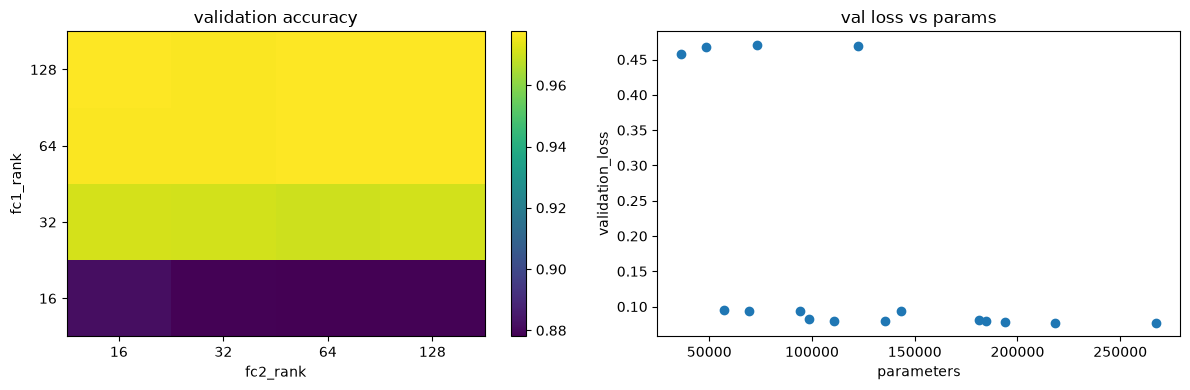

In [7]:
acc_pivot = df.pivot(
    index="fc1_rank",
    columns="fc2_rank",
    values="validation_acc",
)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
im = axes[0].imshow(acc_pivot.values, origin="lower", aspect="auto")
axes[0].set_xticks(range(len(acc_pivot.columns)), acc_pivot.columns)
axes[0].set_yticks(range(len(acc_pivot.index)), acc_pivot.index)
axes[0].set_xlabel("fc2_rank")
axes[0].set_ylabel("fc1_rank")
axes[0].set_title("validation accuracy")
fig.colorbar(im, ax=axes[0])
axes[1].scatter(df["parameters"], df["validation_loss"])
axes[1].set_xlabel("parameters")
axes[1].set_ylabel("validation_loss")
axes[1].set_title("val loss vs params")
plt.tight_layout()
fig.savefig(results_dir / "rank_accuracy_tradeoff_validation.png", dpi=150)
plt.show()


## 7. 最終確認だけ test

validation_loss が最小の 1 組を選び、ここで初めて test を見る。


In [8]:
best = df.iloc[0]
fc1_rank = int(best["fc1_rank"])
fc2_rank = int(best["fc2_rank"])
print("selected from validation:", fc1_rank, fc2_rank)
# corrected: 検証で選んだ 1 組だけ test を見る

final_model = make_two_layer_svd_model(
    model,
    fc1_rank=fc1_rank,
    fc2_rank=fc2_rank,
)
baseline_test_loss, baseline_test_acc = evaluate(
    model, test_loader, criterion, device
)
final_test_loss, final_test_acc = evaluate(
    final_model, test_loader, criterion, device
)
summary = pd.DataFrame(
    [
        {
            "model": "baseline",
            "fc1_rank": "-",
            "fc2_rank": "-",
            "test_loss": baseline_test_loss,
            "test_acc": baseline_test_acc,
        },
        {
            "model": "selected SVD",
            "fc1_rank": fc1_rank,
            "fc2_rank": fc2_rank,
            "test_loss": final_test_loss,
            "test_acc": final_test_acc,
        },
    ]
)
print(summary)
summary.to_csv(results_dir / "test_comparison.csv", index=False)
torch.save(final_model.state_dict(), models_dir / "selected_from_validation.pt")


selected from validation: 128 128


          model fc1_rank fc2_rank  test_loss  test_acc
0      baseline        -        -   0.065442    0.9817
1  selected SVD      128      128   0.065758    0.9808


## 新規runの完全保存

以下は実験記録の保存用。過去runの欠落値を推定せず、このkernelで得た未丸め値・epoch履歴・checkpointを保存する。


In [9]:
# 新しいrunの成果物を不足なく残す。既存のhistorical出力先は使用しない。
import copy
import hashlib
import json
import platform
from datetime import datetime, timezone
import numpy as np
import pandas as pd
import torch
from nn_compression.metrics import benchmark_inference, take_inference_batch, count_parameters

def _run_sha256(path):
    return hashlib.sha256(path.read_bytes()).hexdigest()

_baseline_fit = globals().get("baseline_fit", globals().get("fit"))
assert _baseline_fit is not None
# baseline_stateは圧縮前のsnapshot。FT後checkpointから元重みを推定しない。
_baseline_model = copy.deepcopy(_baseline_fit["model"])
if "baseline_state" in globals():
    _baseline_model.load_state_dict(baseline_state)
torch.save(_baseline_model.state_dict(), models_dir / "baseline_same_run.pt")
pd.DataFrame(_baseline_fit["history"]).to_csv(results_dir / "baseline_history.csv", index=False)
_run_fit_summary = [{
    "stage": "baseline", "best_epoch": _baseline_fit["best_epoch"],
    "best_validation_loss": _baseline_fit["best_validation_loss"],
    "epochs_ran": len(_baseline_fit["history"]),
}]
_run_ft_records = []
if "df_fine_tuned_models" in globals():
    for _, _fit_row in df_fine_tuned_models.iterrows():
        _rank_fields = {c: int(_fit_row[c]) for c in ("fc1_rank", "fc2_rank", "conv2_rank") if c in _fit_row}
        _history_frame = pd.DataFrame(_fit_row["history"]).copy()
        _history_name = "_".join(f"{k}-{v}" for k, v in _rank_fields.items()) + "_ft_history.csv"
        _history_frame.to_csv(results_dir / _history_name, index=False)
        _run_fit_summary.append({
            "stage": "fine_tuning", **_rank_fields,
            "best_epoch": int(_fit_row["best_epoch"]),
            "best_validation_loss": float(_fit_row["best_validation_loss"]),
            "epochs_ran": len(_history_frame),
        })
        for _history_row in _history_frame.to_dict("records"):
            _run_ft_records.append({**_rank_fields, **_history_row})
elif "fine_tune_result" in globals():
    _history_frame = pd.DataFrame(fine_tune_result["history"])
    _history_frame.to_csv(results_dir / "fine_tuning_history.csv", index=False)
    _run_fit_summary.append({
        "stage": "fine_tuning", "conv2_rank": CONV2_RANK, "fc1_rank": FC1_RANK,
        "best_epoch": int(fine_tune_result["best_epoch"]),
        "best_validation_loss": float(fine_tune_result["best_validation_loss"]),
        "epochs_ran": len(_history_frame),
    })
    _run_ft_records = [{ "conv2_rank": CONV2_RANK, "fc1_rank": FC1_RANK, **r } for r in _history_frame.to_dict("records")]
if _run_ft_records:
    pd.DataFrame(_run_ft_records).to_csv(results_dir / "all_fine_tuning_history.csv", index=False)
pd.DataFrame(_run_fit_summary).to_csv(results_dir / "fit_summary.csv", index=False)

_rank_loader = globals().get("validation_loader_rank", globals().get("val_rank_loader"))
assert _rank_loader is not None
_run_inputs = take_inference_batch(_rank_loader)
_run_input_sha256 = hashlib.sha256(_run_inputs.numpy().tobytes()).hexdigest()
_run_warmup = globals().get("BENCH_WARMUP", 20)
_run_repeats = globals().get("BENCH_REPEATS", 2000)
for _name, _filename in (
    ("df_rank_results", "rank_sweep_results.csv"),
    ("df_pareto_view", "pareto_frontier.csv"),
    ("df_pareto_best", "selected_rank_neighbors.csv"),
):
    if _name in globals():
        _frame = globals()[_name].drop(columns=["model", "history"], errors="ignore").copy()
        if _name == "df_rank_results":
            _frame["benchmark_batch_size"] = len(_run_inputs)
            _frame["benchmark_input_shape"] = str(tuple(_run_inputs.shape))
            _frame["benchmark_input_sha256"] = _run_input_sha256
            _frame["benchmark_warmup"] = _run_warmup
            _frame["benchmark_repeats"] = _run_repeats
            _frame["benchmark_stage"] = "rank_sweep_before_finetuning"
        _frame.to_csv(results_dir / _filename, index=False)
_run_test = globals().get("df_test_comparison", globals().get("summary"))
assert _run_test is not None
_run_test.to_csv(results_dir / "test_comparison.csv", index=False)
torch.save(final_model.state_dict(), models_dir / "final_same_run.pt")
_run_benchmarks = []
for _trial in range(1, 4):
    _pairs = [("baseline", _baseline_model), ("final", final_model)]
    if _trial % 2 == 0:
        _pairs.reverse()
    for _label, _benchmark_model in _pairs:
        _details = benchmark_inference(
            _benchmark_model, device=device, input_batch=_run_inputs,
            warmup=_run_warmup, repeats=_run_repeats, return_details=True,
        )
        _run_benchmarks.append({
            "trial": _trial, "model": _label, "time_ms": _details["time_ms"],
            "parameters": count_parameters(_benchmark_model),
            "batch_size": _details["batch_size"], "input_shape": str(_details["input_shape"]),
            "warmup": _run_warmup, "repeats": _run_repeats,
            "stage": "final_after_finetuning" if _run_ft_records else "final_compression_only",
            "input_sha256": _run_input_sha256,
        })
_run_benchmark_frame = pd.DataFrame(_run_benchmarks)
_run_benchmark_frame.to_csv(results_dir / "final_model_benchmark.csv", index=False)
_run_csv_hashes = [
    {"path": p.relative_to(_run_root).as_posix(), "sha256": _run_sha256(p), "bytes": p.stat().st_size}
    for p in sorted(results_dir.iterdir()) if p.suffix in (".csv", ".png")
]
_run_checkpoints = [
    {"path": p.relative_to(_run_root).as_posix(), "sha256": _run_sha256(p), "bytes": p.stat().st_size}
    for p in sorted(models_dir.glob("*.pt"))
]
_run_notebook = _run_root / RUN_NOTEBOOK_RELATIVE
_run_code = json.loads(_run_notebook.read_text(encoding="utf-8"))["cells"]
_run_manifest = {
    "run_id": RUN_BATCH_ID, "experiment": EXPERIMENT_NAME,
    "source_notebook": RUN_SOURCE_RELATIVE, "executed_notebook": RUN_NOTEBOOK_RELATIVE,
    "status": "completed fresh run; NOT reconstruction of historical missing artifacts",
    "completed_at_utc": datetime.now(timezone.utc).isoformat(),
    "code_source_sha256": hashlib.sha256(json.dumps(
        ["".join(c["source"]) for c in _run_code if c["cell_type"] == "code"],
        ensure_ascii=False, separators=(",", ":"),
    ).encode("utf-8")).hexdigest(),
    "source_snapshot_sha256": RUN_SOURCE_SNAPSHOT_SHA256,
    "csv_precision": "direct pandas export of in-memory values; no display rounding",
    "seed": SEED,
    "split_lengths": [len(train_loader.dataset), len(_rank_loader.dataset)],
    "fit_summary": _run_fit_summary,
    "test_records": _run_test.to_dict("records"),
    "benchmark": {
        "warmup": _run_warmup, "repeats": _run_repeats, "trials": 3,
        "input_sha256": _run_input_sha256, "input_shape": list(_run_inputs.shape),
        "definition": "mean forward ms/batch per trial; eval/no_grad; H2D excluded; CUDA synchronized",
        "median_ms": _run_benchmark_frame.groupby("model")["time_ms"].median().to_dict(),
    },
    "environment": {
        "python": platform.python_version(), "torch": str(torch.__version__),
        "cuda": torch.version.cuda, "gpu": torch.cuda.get_device_name(device),
        "cudnn": torch.backends.cudnn.version(),
        "cudnn_benchmark": torch.backends.cudnn.benchmark,
        "cudnn_deterministic": torch.backends.cudnn.deterministic,
        "matmul_tf32": torch.backends.cuda.matmul.allow_tf32,
        "cudnn_tf32": torch.backends.cudnn.allow_tf32,
        "cpu_threads": torch.get_num_threads(),
    },
    "artifacts": _run_csv_hashes, "checkpoints": _run_checkpoints,
}
with (results_dir / "run_manifest.json").open("w", encoding="utf-8") as _f:
    json.dump(_run_manifest, _f, ensure_ascii=False, indent=2)
print("新規run完了:", EXPERIMENT_NAME)
print("成果物:", results_dir)
print("checkpoint:", models_dir)
print(_run_test.to_string(index=False))


新規run完了: 02_rank_accuracy_tradeoff_corrected_rerun_20260912T074153Z
成果物: D:\dev\nn-compression-svd-dmrg\results\10_svd\10_mnist_mlp\02_rank_accuracy_tradeoff_corrected_rerun_20260912T074153Z
checkpoint: D:\dev\nn-compression-svd-dmrg\models\10_svd\10_mnist_mlp\02_rank_accuracy_tradeoff_corrected_rerun_20260912T074153Z
       model fc1_rank fc2_rank  test_loss  test_acc
    baseline        -        -   0.065442    0.9817
selected SVD      128      128   0.065758    0.9808
